In [1]:
from decouple import AutoConfig
config = AutoConfig(search_path='./../.env')

In [2]:
import os
import openai

openai.api_key = config('OPENAI_API_KEY')
os.environ['OPENAI_API_KEY'] = openai.api_key

### Defining the LLM 

In [3]:
from langchain_openai import ChatOpenAI
model_name = 'gpt-4o-mini'
llm = ChatOpenAI(
    model=model_name,
    temperature=0.0,
    max_tokens=1024
)

llm

ChatOpenAI(client=<openai.resources.chat.completions.Completions object at 0x71984fa9abf0>, async_client=<openai.resources.chat.completions.AsyncCompletions object at 0x71984f910ac0>, root_client=<openai.OpenAI object at 0x719860f17610>, root_async_client=<openai.AsyncOpenAI object at 0x71984fa9ac20>, model_name='gpt-4o-mini', temperature=0.0, model_kwargs={}, openai_api_key=SecretStr('**********'), max_tokens=1024)

### Defining the search tools

Using the built-in tools from [Langchain Tools](https://python.langchain.com/docs/integrations/tools/)

In [4]:
from langchain_community.tools.arxiv.tool import ArxivQueryRun
from langchain_community.tools.tavily_search import TavilySearchResults

arxiv_search = ArxivQueryRun()
tavily_tool = TavilySearchResults(max_results=5)

tools = [arxiv_search, tavily_tool]


### Defining the Graph state

In [5]:
from typing import TypedDict, Annotated, List, Union
from IPython.display import Image, display

In [6]:
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    input: str
    agent_outcome: Union[AnyMessage, None]
    chat_history: Annotated[list[AnyMessage], add_messages]

### Initialising the workflow(graph)

In [7]:
from langgraph.graph import StateGraph
workflow = StateGraph(AgentState)

### Defining the agent (node) 

In [8]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

def research_agent(data):
    print("----research node----")
    prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                "You are a helpful AI research assistant chatbot,"
                " Use the appropriate search tools and chat history to progress towards finding the relevant results."
                " Once you have the relevant search results, summarise them to answer the user query."
                "\nYou have access to the following search tools: {tool_names}."
            ),
            (
                "human",
                "\nUser Query: {input}"
            ),
            
            MessagesPlaceholder(variable_name="chat_history"),
        ]
    )
    prompt = prompt.partial(tool_names=", ".join([tool.name for tool in tools]))
    agent = prompt | llm.bind_tools(tools)
    result = agent.invoke(data)
    return {'agent_outcome': [result],
            'chat_history': [result]}

In [9]:
from langgraph.graph import END, StateGraph
workflow = StateGraph(AgentState)

workflow.add_node("research", research_agent)
workflow.set_entry_point("research")

### Defining the ToolNode Class implementation

In [10]:
import json
from langchain_core.messages import ToolMessage

class BasicToolNode:
    def __init__(self, tools: list) -> None:
        self.tools_by_name = {tool.name: tool for tool in tools}

    def __call__(self, inputs: dict):
        print("----tool calling----")
        message = inputs["agent_outcome"][-1]

        outputs = []
        for tool_call in message.tool_calls:
            print(f"---- Calling {tool_call['name']} with args: {tool_call['args']} ----")
            tool_result = self.tools_by_name[tool_call["name"]].invoke(
                tool_call["args"]
            )
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result),
                    name=tool_call["name"],
                    tool_call_id=tool_call["id"],
                )
            )

        return {
                "agent_outcome": outputs,
                "chat_history": outputs
            }

tool_node = BasicToolNode(tools=tools)
workflow.add_node("tools", tool_node)

### Defining the agent-tool router

In [11]:
def route_tools(
    state: AgentState,
):
    """
    Use in the conditional_edge to route to the ToolNode if the last message
    has tool calls. Otherwise, route to the end.
    """
    print("----router----")
    if isinstance(state, list):
        ai_message = state[-1]
    elif agent_outcome := state.get("agent_outcome", []):
        ai_message = agent_outcome[-1]
    else:
        raise ValueError(f"No messages found in input state to tool_edge: {state}")

    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    return END

In [12]:
workflow.add_conditional_edges(
    "research",
    route_tools,
    {"tools": "tools", END: END}
)

In [13]:
workflow.add_edge("tools", "research")

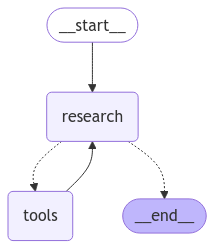

In [14]:
app = workflow.compile()
try:
    display(Image(app.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [15]:
from langchain_core.messages import HumanMessage

inputs = {
    "input": "What are the recent papers on Small Language Models?",
}
inputs["chat_history"] = [HumanMessage(inputs["input"])]
result = app.invoke(inputs)

----research node----
----router----
----tool calling----
---- Calling arxiv with args: {'query': 'Small Language Models'} ----
----research node----
----router----


In [16]:
for msg in result['chat_history']:
    msg.pretty_print()

================================ Human Message =================================

What are the recent papers on Small Language Models?
================================== Ai Message ==================================
Tool Calls:
  arxiv (call_zmQW8pUI5TmEGOLOcNyKFyTq)
 Call ID: call_zmQW8pUI5TmEGOLOcNyKFyTq
  Args:
    query: Small Language Models
================================= Tool Message =================================
Name: arxiv

"Published: 2022-01-26\nTitle: An Assessment of the Impact of OCR Noise on Language Models\nAuthors: Konstantin Todorov, Giovanni Colavizza\nSummary: Neural language models are the backbone of modern-day natural language\nprocessing applications. Their use on textual heritage collections which have\nundergone Optical Character Recognition (OCR) is therefore also increasing.\nNevertheless, our understanding of the impact OCR noise could have on language\nmodels is still limited. We perform an assessment of the impact OCR noise has\non a variety of lang

In [17]:
inputs = {
    "input": "What are the recent papers on Small Language Models?",
}
inputs["chat_history"] = [HumanMessage(inputs["input"])]
state = AgentState(**inputs)
for s in app.stream(input=state):
    list(s.values())[0]['agent_outcome'][0].pretty_print()
    

----research node----
----router----
================================== Ai Message ==================================
Tool Calls:
  arxiv (call_jDQwfQrh1W3cntxzlDVFuxoO)
 Call ID: call_jDQwfQrh1W3cntxzlDVFuxoO
  Args:
    query: Small Language Models
----tool calling----
---- Calling arxiv with args: {'query': 'Small Language Models'} ----
================================= Tool Message =================================
Name: arxiv

"Published: 2022-01-26\nTitle: An Assessment of the Impact of OCR Noise on Language Models\nAuthors: Konstantin Todorov, Giovanni Colavizza\nSummary: Neural language models are the backbone of modern-day natural language\nprocessing applications. Their use on textual heritage collections which have\nundergone Optical Character Recognition (OCR) is therefore also increasing.\nNevertheless, our understanding of the impact OCR noise could have on language\nmodels is still limited. We perform an assessment of the impact OCR noise has\non a variety of language mo